In [ ]:
# Add the project root to sys.path so that the src/ modules can be imported from the notebooks/ subdirectory
import sys
import os
sys.path.insert(0, os.path.abspath('..'))  
# goes up one level from notebooks/ to project root

In [ ]:
# Import project modules for data extraction, event decoding, metrics, survival analysis and Merkl campaigns
from src.extract import hypersync_indexer
import src.decode_events as de
import src.metrics as m
import src.survival_analysis as surv
import src.merkl_campaigns as merkl

# Target pool URL on Merkl — identifies the chain, pool type, and contract address
merkl_URL = "https://app.merkl.xyz/opportunities/celo/CLAMM/0xF55791AfBB35aD42984f18D6Fe3e1fF73D81900c"

# Parse chain name, pool type, and block explorer address from the URL
chain_name, type, explorer_address = merkl.parse_merkl_URL(merkl_URL)

# Fetch opportunity details: unique ID and token metadata (symbol, decimals, is_usd flag)
opportunityId, token0, token1 = merkl.get_opportunity_details(merkl_URL)

# Fetch all incentive campaigns associated with this pool opportunity
campaigns = merkl.get_campaigns(opportunityId)

# Extract token decimals for later price/amount normalization
DECIMALS0 = token0["decimals"]
DECIMALS1 = token1["decimals"]

# Build a human-readable pool pair label and output path for the events data
pool_pair = token0["symbol"].values[0].lower() + "_" + token1["symbol"].values[0].lower()
out_path = "data/" + chain_name + "_" + pool_pair + "_events"

In [ ]:
# Override out_path to point one level up (project root) since notebook runs from notebooks/
out_path = "../" + chain_name + "_" + pool_pair + "_events"

# Build file paths for the raw logs and block data stored as Parquet
logs_path = out_path + "/logs.parquet"
blocks_path = out_path + "/blocks.parquet"

# Load and merge logs with block metadata into a single DataFrame
pool_events = de.load_events(logs_path, blocks_path)

pool_events.head()

,timestamp,log_index,transaction_index,transaction_hash,block_number,address,data,topic0,topic1,topic2,topic3
0,1743751735,4,4,0xf188274281961c438a67e69bbbed7ae7df29e3393f3d...,31850977,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0x0000000000000000000000000000000000005a9e9ad1...,0x98636036cb66a9c19a37435efc1e90142190214e8abe...,None,None,None
1,1743751735,8,4,0xf188274281961c438a67e69bbbed7ae7df29e3393f3d...,31850977,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0x0000000000000000000000003d79edaabc0eab6f08ed...,0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85...,0x0000000000000000000000003d79edaabc0eab6f08ed...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x00000000000000000000000000000000000000000000...
2,1743751994,8,1,0xdf041e706b428593762407ef93ad18fa23052f3f5a93...,31851236,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x000000000000000000000000992527152b5637c175be...,0x000000000000000000000000992527152b5637c175be...,None
3,1743765717,5,3,0xbb9a79b7e7069cb76ef200258ebfc274ca25da70dc59...,31864959,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x00000000000000000000000000000000000130ced602...,0x00000000000000000000000000000000000130ced602...,None
4,1743779902,5,2,0x42ffae597902869fb679d47512d6b011e8d9a1c0493e...,31879144,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0x00000000000000000000000000000000000000000000...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x00000000000000000000000000000000000130ced602...,0x00000000000000000000000000000000000130ced602...,None


In [ ]:
# Decode topic0 hashes into human-readable event names (Mint, Burn, Swap, Initialize, etc.)
pool_events = de.decode_topic0(pool_events)

# Record the pool's initialization timestamp as the reference start time
INITIAL_TIMESTAMP = pool_events[pool_events["event"] == "Initialize"]["timestamp"].iloc[0]

# Decode each event type into structured DataFrames with typed fields
mint_events_decoded = de.decode_mint_events(pool_events[pool_events["event"] == "Mint"])
burn_events_decoded = de.decode_burn_events(pool_events[pool_events["event"] == "Burn"])
swap_events_decoded = de.decode_swap_events(pool_events[pool_events["event"] == "Swap"])

In [ ]:
# Print a high-level summary of the pool and event counts
print(f"Chain: {chain_name}")
print(f"Pool pair: {pool_pair}")
print(f"Total mint events: {len(mint_events_decoded)}")
print(f"Total burn events: {len(burn_events_decoded)}")
print(f"Total swap events: {len(swap_events_decoded)}")

Chain: celo
Pool pair: usd₮_weth
Total mint events: 107768
Total burn events: 113445
Total swap events: 1692614


In [ ]:
# Preview the first few decoded mint events (liquidity additions)
mint_events_decoded.head()

,timestamp,log_index,transaction_index,transaction_hash,block_number,address,data,topic0,topic1,topic2,topic3,event,sender,owner,tickLower,tickUpper,amount,amount0,amount1
1,1743751735,8,4,0xf188274281961c438a67e69bbbed7ae7df29e3393f3d...,31850977,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0x0000000000000000000000003d79edaabc0eab6f08ed...,0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85...,0x0000000000000000000000003d79edaabc0eab6f08ed...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x00000000000000000000000000000000000000000000...,Mint,0x3d79edaabc0eab6f08ed885c05fc0b014290d95a,0x3d79edaabc0eab6f08ed885c05fc0b014290d95a,-887272,887272,2319860475568,100000000,53817526261067376
38,1744136248,59,13,0x083516b6bf24732db775bbc20cb9edcfc9b43d037680...,32235490,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0x000000000000000000000000b98a8247c410a81b34d1...,0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85...,0x000000000000000000000000b98a8247c410a81b34d1...,0x00000000000000000000000000000000000000000000...,0x00000000000000000000000000000000000000000000...,Mint,0xb98a8247c410a81b34d1e3f93709053bc078190f,0xb98a8247c410a81b34d1e3f93709053bc078190f,199582,203148,5499761863040001,0,23142772320535914394
39,1744136248,65,13,0x083516b6bf24732db775bbc20cb9edcfc9b43d037680...,32235490,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0x00000000000000000000000046689e56af9b3c9f7d88...,0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85...,0x00000000000000000000000046689e56af9b3c9f7d88...,0x00000000000000000000000000000000000000000000...,0x00000000000000000000000000000000000000000000...,Mint,0x46689e56af9b3c9f7d88f2a987264d07c0815e14,0x46689e56af9b3c9f7d88f2a987264d07c0815e14,203150,206716,7998312727515967,50682964689,0
127,1744147405,13,1,0xb5a553e9df0e4e26f1b7427d367652bc8af3091cb124...,32246647,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0x000000000000000000000000b98a8247c410a81b34d1...,0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85...,0x000000000000000000000000b98a8247c410a81b34d1...,0x00000000000000000000000000000000000000000000...,0x00000000000000000000000000000000000000000000...,Mint,0xb98a8247c410a81b34d1e3f93709053bc078190f,0xb98a8247c410a81b34d1e3f93709053bc078190f,203335,887272,376211009,14464,9403290
128,1744147405,15,1,0xb5a553e9df0e4e26f1b7427d367652bc8af3091cb124...,32246647,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0x000000000000000000000000b98a8247c410a81b34d1...,0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85...,0x000000000000000000000000b98a8247c410a81b34d1...,0x00000000000000000000000000000000000000000000...,0x00000000000000000000000000000000000000000000...,Mint,0xb98a8247c410a81b34d1e3f93709053bc078190f,0xb98a8247c410a81b34d1e3f93709053bc078190f,199768,203334,5448855971991903,0,23142781915607762017


In [ ]:
# Preview the first few decoded burn events (liquidity removals)
burn_events_decoded.head()

,timestamp,log_index,transaction_index,transaction_hash,block_number,address,data,topic0,topic1,topic2,topic3,event,sender,recipient,amount0,amount1,sqrtPriceX96,liquidity,tick
2,1743751994,8,1,0xdf041e706b428593762407ef93ad18fa23052f3f5a93...,31851236,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x000000000000000000000000992527152b5637c175be...,0x000000000000000000000000992527152b5637c175be...,None,Swap,0x992527152b5637c175be811a4fbc381e30b5c146,0x992527152b5637c175be811a4fbc381e30b5c146,-1541187,842496717923253,1866753002723531555193912983284309,2319860475568,201357
3,1743765717,5,3,0xbb9a79b7e7069cb76ef200258ebfc274ca25da70dc59...,31864959,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x00000000000000000000000000000000000130ced602...,0x00000000000000000000000000000000000130ced602...,None,Swap,0x00000000000130ced6024c216d5636f216173feb,0x00000000000130ced6024c216d5636f216173feb,-422748,235726744070311,1874802766649058084291400427541483,2319860475568,201443
4,1743779902,5,2,0x42ffae597902869fb679d47512d6b011e8d9a1c0493e...,31879144,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0x00000000000000000000000000000000000000000000...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x00000000000000000000000000000000000130ced602...,0x00000000000000000000000000000000000130ced602...,None,Swap,0x00000000000130ced6024c216d5636f216173feb,0x00000000000130ced6024c216d5636f216173feb,430785,-240139850663870,1866601480703234144416680573434635,2319860475568,201356
7,1743869440,7,2,0x58baaab1e18b01c598a6dced3b6770b63d2badce3ad1...,31968682,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x000000000000000000000000643770e279d5d0733f21...,0x000000000000000000000000643770e279d5d0733f21...,None,Swap,0x643770e279d5d0733f21d6dc03a8efbabf3255b4,0x643770e279d5d0733f21d6dc03a8efbabf3255b4,-304229,169407764647603,1872386537116509057589263206911600,2319860475568,201417
8,1743947034,15,5,0xa2ff69a8d7e3872ada6decc7860fc46817e3fde9b882...,32046276,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x000000000000000000000000643770e279d5d0733f21...,0x000000000000000000000000643770e279d5d0733f21...,None,Swap,0x643770e279d5d0733f21d6dc03a8efbabf3255b4,0x643770e279d5d0733f21d6dc03a8efbabf3255b4,-315519,176807425185278,1878424282382261152053386016569778,2319860475568,201482


In [ ]:
# Preview the first few decoded swap events (token exchanges)
swap_events_decoded.head()

,timestamp,log_index,transaction_index,transaction_hash,block_number,address,data,topic0,topic1,topic2,topic3,event,sender,recipient,amount0,amount1,sqrtPriceX96,liquidity,tick
2,1743751994,8,1,0xdf041e706b428593762407ef93ad18fa23052f3f5a93...,31851236,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x000000000000000000000000992527152b5637c175be...,0x000000000000000000000000992527152b5637c175be...,None,Swap,0x992527152b5637c175be811a4fbc381e30b5c146,0x992527152b5637c175be811a4fbc381e30b5c146,-1541187,842496717923253,1866753002723531555193912983284309,2319860475568,201357
3,1743765717,5,3,0xbb9a79b7e7069cb76ef200258ebfc274ca25da70dc59...,31864959,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x00000000000000000000000000000000000130ced602...,0x00000000000000000000000000000000000130ced602...,None,Swap,0x00000000000130ced6024c216d5636f216173feb,0x00000000000130ced6024c216d5636f216173feb,-422748,235726744070311,1874802766649058084291400427541483,2319860475568,201443
4,1743779902,5,2,0x42ffae597902869fb679d47512d6b011e8d9a1c0493e...,31879144,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0x00000000000000000000000000000000000000000000...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x00000000000000000000000000000000000130ced602...,0x00000000000000000000000000000000000130ced602...,None,Swap,0x00000000000130ced6024c216d5636f216173feb,0x00000000000130ced6024c216d5636f216173feb,430785,-240139850663870,1866601480703234144416680573434635,2319860475568,201356
7,1743869440,7,2,0x58baaab1e18b01c598a6dced3b6770b63d2badce3ad1...,31968682,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x000000000000000000000000643770e279d5d0733f21...,0x000000000000000000000000643770e279d5d0733f21...,None,Swap,0x643770e279d5d0733f21d6dc03a8efbabf3255b4,0x643770e279d5d0733f21d6dc03a8efbabf3255b4,-304229,169407764647603,1872386537116509057589263206911600,2319860475568,201417
8,1743947034,15,5,0xa2ff69a8d7e3872ada6decc7860fc46817e3fde9b882...,32046276,0xf55791afbb35ad42984f18d6fe3e1ff73d81900c,0xffffffffffffffffffffffffffffffffffffffffffff...,0xc42079f94a6350d7e6235f29174924f928cc2ac818eb...,0x000000000000000000000000643770e279d5d0733f21...,0x000000000000000000000000643770e279d5d0733f21...,None,Swap,0x643770e279d5d0733f21d6dc03a8efbabf3255b4,0x643770e279d5d0733f21d6dc03a8efbabf3255b4,-315519,176807425185278,1878424282382261152053386016569778,2319860475568,201482


In [ ]:
# Compute TVL over time by combining mint, burn, and swap events
# Token decimals and USD flags are used to normalize amounts to a common unit
#import importlib
#importlib.reload(m)
tvl_variation = m.tvl(mint_events_decoded,
                          burn_events_decoded,
                          swap_events_decoded,
                          DECIMALS0,
                          DECIMALS1,
                          token0["is_usd"].values[0],
                          token1["is_usd"].values[0]
                          )

c:\Users\PC\Desktop\coding\uniswap-lp-analysis\src\metrics.py:122: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  tvl_variation["delta_tvl_pct"] = tvl_variation["tvl_relative"].pct_change() * 100
c:\Users\PC\Desktop\coding\uniswap-lp-analysis\src\metrics.py:122: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tvl_variation["delta_tvl_pct"] = tvl_variation["tvl_relative"].pct_change() * 100


In [ ]:
# Preview the TVL time series (timestamp + token amounts + total USD value)
tvl_variation.head()

,timestamp,block_number,transaction_index,log_index,event,owner,tickLower,tickUpper,amount,amount0,...,cumulative_amount1_HRF,event_order,price1_per0_hrf,tvl_token0_units,tvl_token1_units,tvl_relative,delta_tvl_pct,price0_usd,price1_usd,tvl_usd
0,1743751735,31850977,4,8,Mint,0x3d79edaabc0eab6f08ed885c05fc0b014290d95a,-887272,887272,2319860475568,100000000,...,0.053818,31850977000004008,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN
1,1744136248,32235490,13,59,Mint,0xb98a8247c410a81b34d1e3f93709053bc078190f,199582,203148,5499761863040001,0,...,NaN,32235490000013059,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN
2,1744136248,32235490,13,65,Mint,0x46689e56af9b3c9f7d88f2a987264d07c0815e14,203150,206716,7998312727515967,50682964689,...,NaN,32235490000013065,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN
3,1744147405,32246647,1,2,Burn,0xb98a8247c410a81b34d1e3f93709053bc078190f,199582,203148,5499761863040001,0,...,NaN,32246647000001002,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN
4,1744147405,32246647,1,13,Mint,0xb98a8247c410a81b34d1e3f93709053bc078190f,203335,887272,376211009,14464,...,NaN,32246647000001013,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN


In [ ]:
# Build per-LP summary: tracks entry/exit counts and whether each LP has fully exited
_ , lp_summary = m.verify_lp_exit(mint_events_decoded, burn_events_decoded)

# Tag each LP with whether they entered during an active Merkl incentive campaign
lp_summary = merkl.entered_during_campaign(lp_summary, campaigns)

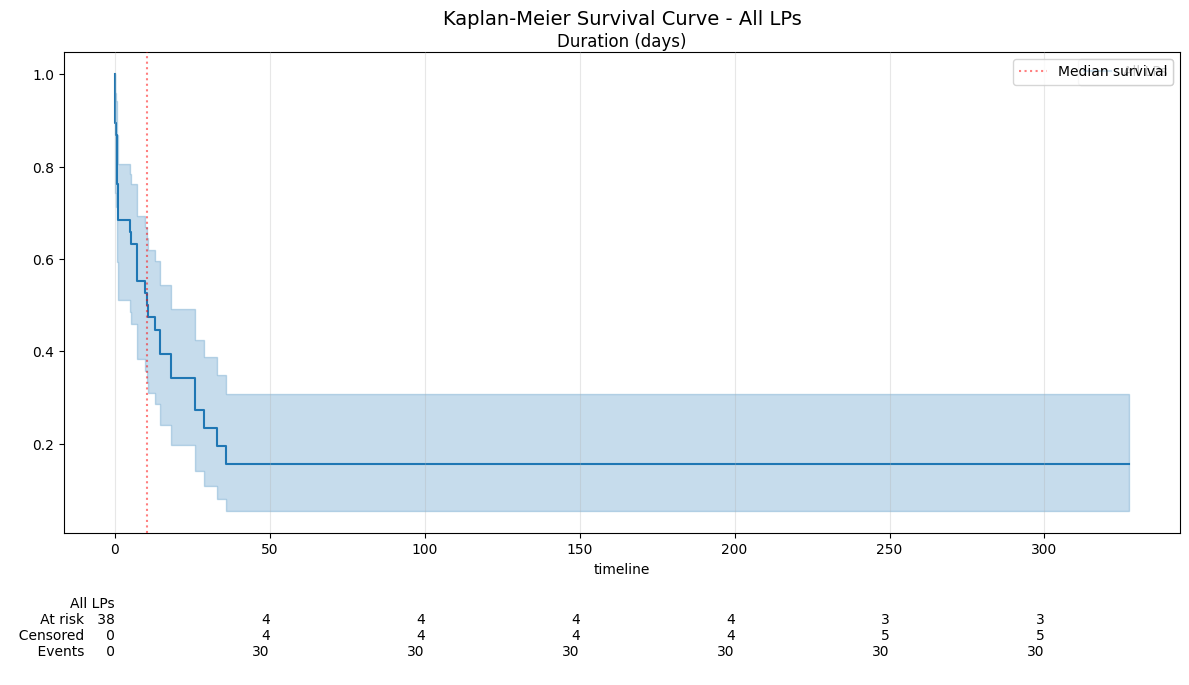

In [ ]:
# Survival analysis — estimates how long LPs stay in the pool before exiting

# Kaplan-Meier estimator: plots the survival curve across all LPs
kmf = surv.km_scurve(lp_summary)

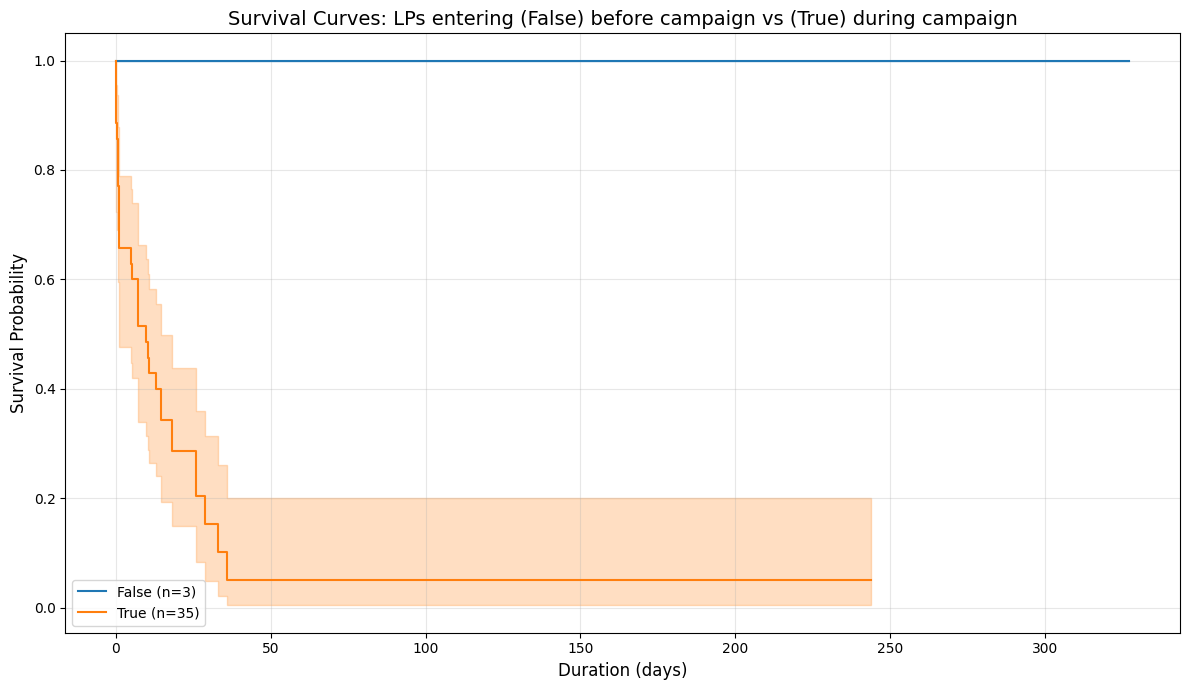

In [ ]:
# Segmented Kaplan-Meier: compares survival curves for LPs who entered during a campaign vs. those who didn't
kmf_segmented = surv.km_scurve_segmented(lp_summary)

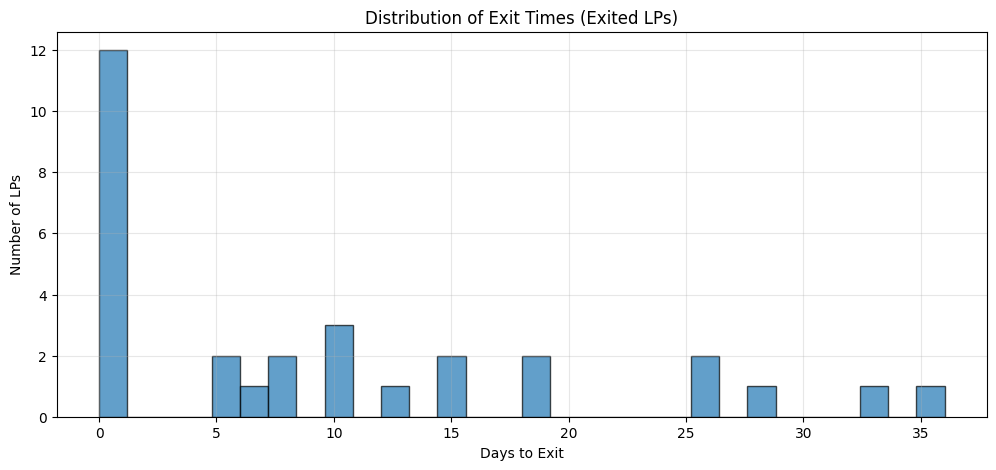

In [ ]:
# Plot the distribution of LP exit times (histogram of how long LPs held their position)
surv.exit_time_distribution(lp_summary)